## USGS Data Retrieval

In [16]:
import os
import cdsapi
import pandas as pd
import numpy as np
import pyproj
import pygrib
import xarray as xr
import s3fs
import dataretrieval.nwis as nwis
from google.cloud import storage
from datetime import datetime, timedelta, date
import json
import matplotlib.pyplot as plt
from haversine import haversine, Unit
import warnings
import geopandas as gpd
from shapely.geometry import Point
import resource
from pyproj import Transformer
import pickle
from collections import defaultdict
import subprocess
from pathlib import Path
import requests
from pytz import utc

In [17]:
# Constants
CFSToCMS_CONVERSION_FACTOR = 0.0283168466

# Define time range
start_usgs = '1979-01-01'

today = datetime.today()
# Format it as YYYY-MM-DD
end_usgs = today.strftime('%Y-%m-%d')

# Convert end date to datetime object and get start date for forecast
end_usgs_datetime = datetime.strptime(end_usgs, '%Y-%m-%d')
start_forecast_datetime = end_usgs_datetime - timedelta(days=1)
start_forecast = start_forecast_datetime.strftime('%Y-%m-%d')

# Specify the USGS site code
site_code = '11467000'

# Fetch daily data for the site
df = nwis.get_record(sites=site_code, service='dv', parameterCd='00060', statCd='00003',
                     start=start_usgs, end=end_usgs)

# Log-transform the flow data; we add 1 to handle cases where the value is 0
df['log_discharge'] = np.log(df['00060_Mean'].astype(float) + 1)

# Keep only the relevant column
df = df[['log_discharge']]

# Reverse the log transformation to get back the discharge in cfs
df['discharge_cfs'] = np.exp(df['log_discharge']) - 1

# Convert discharge from cfs to cms
df['discharge_cms'] = df['discharge_cfs'] * CFSToCMS_CONVERSION_FACTOR

# Optionally, log-transform the discharge in cms
df['log_discharge_cms'] = np.log(df['discharge_cms'] + 1)

In [18]:
# Fetch metadata for the USGS site without specifying fields
site_info = nwis.get_record(sites=site_code, service='site')

# Extract latitude and longitude
latitude = float(site_info['dec_lat_va'][0])
longitude = float(site_info['dec_long_va'][0])

# Combine into a single target_location tuple
target_location = (latitude, longitude)
target_lat, target_lon = target_location
print(f"The coordinates for site {site_code} are {target_location}")


The coordinates for site 11467000 are (38.50852336, -122.9277737)


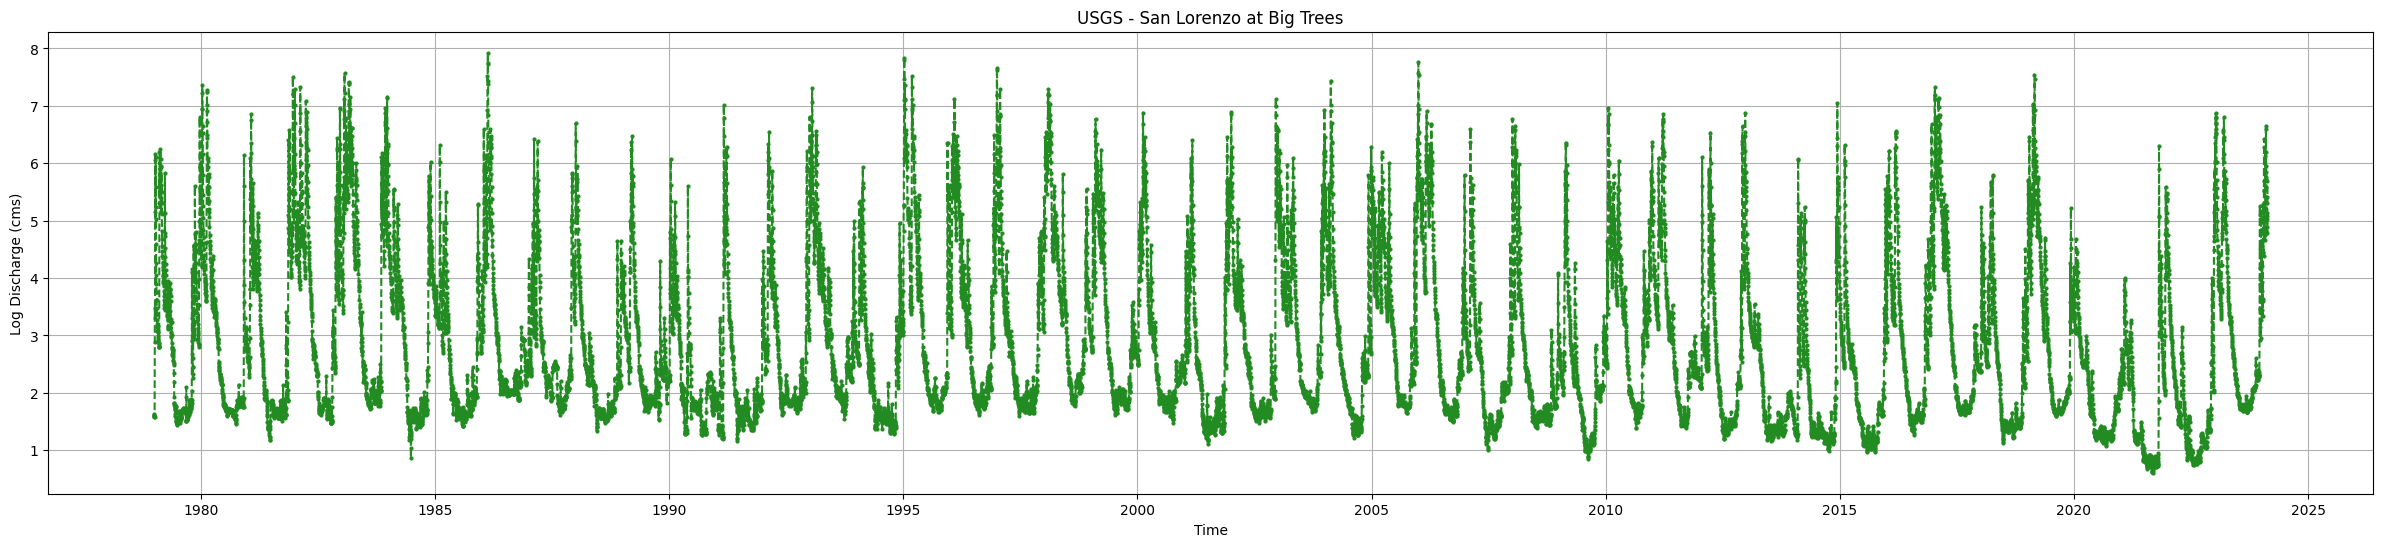

Figure saved at /home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/usgs_figures/usgs_russian_20240219.png


In [19]:
# Get today's date in YYYYMMDD format
today_date = datetime.now().strftime("%Y%m%d")

# Create a new figure
plt.figure(figsize=(30, 6))

# Plotting
plt.plot(np.array(df.index), np.array(df['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1)

# Adding labels, title, and grid
plt.xlabel('Time')
plt.ylabel('Log Discharge (cms)')
plt.title('USGS - San Lorenzo at Big Trees')
plt.grid(True)

# # Save the figure
# save_path = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/usgs_figures/usgs_russian_{today_date}.png"
# plt.savefig(save_path)

# Show the plot
plt.show()

print(f"Figure saved at {save_path}")


### Forecast Start Date:

In [20]:
start_forecast = '2020-01-01'

In [21]:
# Convert to datetime object
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')

# Calculate the start and end date for filtering
start_filter_dt = start_forecast_dt - timedelta(days=10)
end_filter_dt = start_forecast_dt + timedelta(days=45)

# Convert back to string
start_filter_str = start_filter_dt.strftime('%Y-%m-%d')
end_filter_str = end_filter_dt.strftime('%Y-%m-%d')

# Filter the DataFrame
df_filtered = df.loc[start_filter_str:end_filter_str]


In [22]:
# Convert to datetime object
start_forecast_dt_s = datetime.strptime(start_forecast, '%Y-%m-%d')

# Calculate the start and end date for filtering
start_filter_dt_s = start_forecast_dt_s - timedelta(days=30)
end_filter_dt_s = start_forecast_dt_s + timedelta(days=270)

# Convert back to string
start_filter_str_s = start_filter_dt_s.strftime('%Y-%m-%d')
end_filter_str_s = end_filter_dt_s.strftime('%Y-%m-%d')

# Filter the DataFrame
df_filtered_s = df.loc[start_filter_str_s:end_filter_str_s]

In [23]:
def convert_date_format(date_str):
    """
    Convert a date string from 'YYYY-MM-DD' to 'YYYYMMDD'
    
    Parameters:
        date_str (str): Date string in 'YYYY-MM-DD' format
    
    Returns:
        str: Date string in 'YYYYMMDD' format
    """
    return date_str.replace("-", "")

# Example usage
start_forecast_joint = convert_date_format(start_forecast)

## GloFAS Data Retrieval
- Mean discharge in the last 24 hours:m^3 s^-1 (avg):

In [ ]:
def retrieve_glofas_data_medium(
    start_forecast,
    target_location,
    buffer=1,
    system_version='operational',
    hydrological_model='lisflood',
    product_type=['control_forecast','ensemble_perturbed_forecasts'],
    variable='river_discharge_in_the_last_24_hours',
    leadtime_hour= [str(i) for i in range(24, 721, 24)],
    target_folder='/home/antonio/UCSC/Research/GloFAS_data/'
):
    # Extract year, month, day from end_usgs
    dt = datetime.strptime(start_forecast, '%Y-%m-%d')
    year, month, day = dt.year, dt.month, dt.day

    # Create a bounding box around the target location
    latitude, longitude = target_location
    area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]
    
    # Shorten the elements for the filename
    short_product_type = '_'.join(''.join(word[0] for word in item.split('_')) for item in product_type)
    short_variable = ''.join(word[0] for word in variable.split('_'))
    
    # Create a shorter filename
    file_name_elements = [
        system_version[:3], 
        hydrological_model[:3], 
        short_product_type,
        short_variable,
        str(year), str(month).zfill(2), str(day).zfill(2),
        f"lt_{leadtime_hour[0]}_to_{leadtime_hour[-1]}", 
        f"area_{round(area[0], 2)}_{round(area[1], 2)}_{round(area[2], 2)}_{round(area[3], 2)}"
    ]
    file_name = '_'.join(file_name_elements) + '.grib'
    
    # Construct the full path of the output file
    output_file = os.path.join(target_folder, file_name)
    
    # Check if the file already exists
    if os.path.exists(output_file):
        print(f"File already exists: {output_file}")
        return output_file
    
    # Initialize the CDS API client
    c = cdsapi.Client()
    
    # Construct the retrieval parameters
    retrieval_params = {
        'system_version': system_version,
        'hydrological_model': hydrological_model,
        'product_type': product_type,
        'variable': variable,
        'year': str(year),
        'month': str(month).zfill(2),
        'day': str(day).zfill(2),
        'leadtime_hour': leadtime_hour,
        'format': 'grib',
        'area': area
    }
    
    # Perform the retrieval
    c.retrieve('cems-glofas-forecast', retrieval_params, output_file)
    print(f"Retrieval completed. Output file saved to: {output_file}")

    # Return the output_file path
    return output_file

In [ ]:
def retrieve_glofas_data_seasonal(
    start_forecast,
    target_location,
    buffer=1,
    system_version='operational',
    hydrological_model='lisflood',
    product_type=['control_forecast', 'ensemble_perturbed_forecasts'],
    variable='river_discharge_in_the_last_24_hours',
    leadtime_hour = [str(i) for i in range(24, 5161, 24)],
    target_folder='/home/antonio/UCSC/Research/GloFAS_data/',
    leadtime_chunk_size=50  # Specify the size of each leadtime chunk
):
    # Extract year, month, day from start_forecast
    dt = datetime.strptime(start_forecast, '%Y-%m-%d')
    year, month, day = dt.year, dt.month, dt.day

    # Create a bounding box around the target location
    latitude, longitude = target_location
    area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]

    # Initialize the CDS API client
    c = cdsapi.Client()

    # Divide the leadtime_hour into chunks
    chunks = [leadtime_hour[i:i + leadtime_chunk_size] for i in range(0, len(leadtime_hour), leadtime_chunk_size)]

    output_files = []  # List to store the paths of downloaded files

    for chunk in chunks:
        # Shorten the elements for the filename
        short_product_type = '_'.join(''.join(word[0] for word in item.split('_')) for item in product_type)
        short_variable = ''.join(word[0] for word in variable.split('_'))

        # Create a shorter filename
        file_name_elements = [
            system_version[:3],
            hydrological_model[:3],
            short_product_type,
            short_variable,
            str(year), str(month).zfill(2), str(day).zfill(2),
            f"lt_{chunk[0]}_to_{chunk[-1]}",
            f"area_{round(area[0], 2)}_{round(area[1], 2)}_{round(area[2], 2)}_{round(area[3], 2)}"
        ]
        chunk_filename = 'seas_' + '_'.join(file_name_elements) + '.grib'

        # Construct the full path of the output file
        output_file = os.path.join(target_folder, chunk_filename)

        # Check if the file already exists
        if os.path.exists(output_file):
            print(f"File already exists: {output_file}")
            output_files.append(output_file)
            continue

        # Construct the retrieval parameters
        retrieval_params = {
            'system_version': system_version,
            'hydrological_model': hydrological_model,
            'product_type': product_type,
            'variable': variable,
            'year': str(year),
            'month': str(month).zfill(2),
            'day': str(day).zfill(2),
            'leadtime_hour': chunk,
            'format': 'grib',
            'area': area
        }

        # Perform the retrieval
        c.retrieve('cems-glofas-seasonal', retrieval_params, output_file)
        print(f"Retrieval completed. Output file saved to: {output_file}")
        output_files.append(output_file)

    return output_files




In [ ]:
# Call the function with a small leadtime_chunk_size for testing
output_files = retrieve_glofas_data_seasonal(start_forecast, target_location, leadtime_chunk_size=120)


In [ ]:
def get_common_prefix(strings):
    if not strings:
        return ""
    
    prefix = os.path.commonprefix(strings)
    # Remove the last part to get up to the last common '_'
    prefix = '_'.join(prefix.split('_')[:-1])
    return prefix

def merge_grib_files(output_files):
    common_prefix = get_common_prefix(output_files)
    
    # Define the name of the merged file based on the common prefix
    merged_file_name = f"{common_prefix}_merged.grib"
    merged_file_name = os.path.join('/home/antonio/UCSC/Research/GloFAS_data', merged_file_name)
    
    merge_command = ["grib_copy"] + output_files + [merged_file_name]
    subprocess.run(merge_command)
    
    print(f"Merged file saved to: {merged_file_name}")
    return merged_file_name

# Example usage
merged_file_name = merge_grib_files(output_files)

In [ ]:
# Example of how to call the function
grib_file_path = retrieve_glofas_data_medium(start_forecast=start_forecast, target_location=target_location)

In [ ]:
grbs = pygrib.open(grib_file_path)
# Initialize sets to store unique lead times and ensemble members
unique_lead_times = set()
unique_ensemble_members = set()

# Loop through the grib messages to populate the sets
for grb in grbs:
    unique_lead_times.add(grb['forecastTime'])
    unique_ensemble_members.add(grb['perturbationNumber'])

# Reset the iterator to the start
grbs.seek(0)


In [ ]:
grbs_s = pygrib.open(merged_file_name)
# Initialize sets to store unique lead times and ensemble members
unique_lead_times_s = set()
unique_ensemble_members_s = set()

# Loop through the grib messages to populate the sets
for grb in grbs_s:
    unique_lead_times_s.add(grb['forecastTime'])
    unique_ensemble_members_s.add(grb['perturbationNumber'])

# Reset the iterator to the start
grbs_s.seek(0)

In [ ]:
def convert_longitude_to_0_360(lon):
    """
    Convert a longitude from the range [-180, 180] to [0, 360].
    """
    return lon % 360

def convert_longitude_to_neg_180_180(lon):
    """
    Convert a longitude from the range [0, 360] to [-180, 180].
    """
    if lon > 180:
        return lon - 360
    return lon


In [ ]:
# Find the closest coordinates for the first ensemble member
min_distance = float('inf')
closest_coordinates = None
closest_i = None  # Initialize variables to store the indices
closest_j = None

# Your existing loop
for grb in grbs:
    if grb['perturbationNumber'] == 0:
        latitudes, longitudes = grb.latlons()
        for i in range(len(latitudes)):
            for j in range(len(longitudes[0])):
                coord = (latitudes[i][j], convert_longitude_to_neg_180_180(longitudes[i][j]))
                distance = haversine(target_location, coord, unit=Unit.METERS )
                if distance < min_distance:
                    min_distance = distance
                    closest_coordinates = coord
                    closest_i = i  # Store the index i
                    closest_j = j  # Store the index j
        break

# If you need closest_coordinates in [0, 360], you can convert it back.
closest_coordinates_glofas = (closest_coordinates[0], convert_longitude_to_0_360(closest_coordinates[1]))

# Now you also have closest_i and closest_j which are the indices for closest_coordinates in the GloFAS grid.
print("Closest Coordinates in GloFAS format:", closest_coordinates_glofas)
# print("Indices in the GloFAS grid:", closest_i, closest_j)

In [ ]:
# Find the closest coordinates for the first ensemble member
min_distance_s = float('inf')
closest_coordinates_s = None
closest_i_s = None  # Initialize variables to store the indices
closest_j_s = None

# Your existing loop
for grb in grbs_s:
    if grb['perturbationNumber'] == 0:
        latitudes_s, longitudes_s = grb.latlons()
        for i in range(len(latitudes_s)):
            for j in range(len(longitudes_s[0])):
                coord_s = (latitudes_s[i][j], convert_longitude_to_neg_180_180(longitudes_s[i][j]))
                distance_s = haversine(target_location, coord_s, unit=Unit.METERS )
                if distance_s < min_distance_s:
                    min_distance_s = distance_s
                    closest_coordinates_s = coord_s
                    closest_i_s = i  # Store the index i
                    closest_j_s = j  # Store the index j
        break

# If you need closest_coordinates in [0, 360], you can convert it back.
closest_coordinates_glofas_s = (closest_coordinates_s[0], convert_longitude_to_0_360(closest_coordinates_s[1]))

# Now you also have closest_i and closest_j which are the indices for closest_coordinates in the GloFAS grid.
print("Closest Coordinates in GloFAS format:", closest_coordinates_glofas_s)
# print("Indices in the GloFAS grid:", closest_i, closest_j)

In [ ]:
# Initialize a dictionary to store the data
# This will hold data in the form: {(ensemble_member, lead_time): value}
glofas_data = {}

# Loop through each message (ensemble member and lead time)
for grb in grbs:
    # Extract the lead time and ensemble member from the message
    lead_time = grb['forecastTime']
    ensemble_member = grb['perturbationNumber']
    
    # Extract the data value at the closest coordinates as a single value
    data_value = grb.values[closest_i, closest_j]
    
    # Store the data in the dictionary
    glofas_data[(ensemble_member, lead_time)] = data_value

# Close the GloFAS data file
grbs.close()

# Step 1: Sort the unique ensemble members and lead times
sorted_ensemble_members = sorted(list(unique_ensemble_members))
sorted_lead_times = sorted(list(unique_lead_times))

# Step 2: Create dictionaries for mapping
ensemble_member_to_idx = {ensemble_member: idx for idx, ensemble_member in enumerate(sorted_ensemble_members)}
lead_time_to_idx = {lead_time: idx for idx, lead_time in enumerate(sorted_lead_times)}

# Step 3: Initialize the array and populate it
num_ensemble_members = len(sorted_ensemble_members)
num_lead_times = len(sorted_lead_times)
glofas_array = np.zeros((num_ensemble_members, num_lead_times))

for (ensemble_member, lead_time), value in glofas_data.items():
    i = ensemble_member_to_idx[ensemble_member]
    j = lead_time_to_idx[lead_time]
    glofas_array[i, j] = value

# print("GloFAS Data Array:", glofas_array)

In [ ]:
# Initialize a dictionary to store the data
# This will hold data in the form: {(ensemble_member, lead_time): value}
glofas_data_s = {}

# Loop through each message (ensemble member and lead time)
for grb in grbs_s:
    # Extract the lead time and ensemble member from the message
    lead_time_s = grb['forecastTime']
    ensemble_member_s = grb['perturbationNumber']
    
    # Extract the data value at the closest coordinates as a single value
    data_value_s = grb.values[closest_i_s, closest_j_s]
    
    # Store the data in the dictionary
    glofas_data_s[(ensemble_member_s, lead_time_s)] = data_value_s

# Close the GloFAS data file
grbs_s.close()

# Step 1: Sort the unique ensemble members and lead times
sorted_ensemble_members_s = sorted(list(unique_ensemble_members_s))
sorted_lead_times_s = sorted(list(unique_lead_times_s))

# Corrected Step 2: Create dictionaries for mapping
ensemble_member_to_idx_s = {ensemble_member: idx for idx, ensemble_member in enumerate(sorted_ensemble_members_s)}
lead_time_to_idx_s = {lead_time: idx for idx, lead_time in enumerate(sorted_lead_times_s)}

# Step 3: Initialize the array and populate it
num_ensemble_members_s = len(sorted_ensemble_members_s)
num_lead_times_s = len(sorted_lead_times_s)
glofas_array_s = np.zeros((num_ensemble_members_s, num_lead_times_s))

for (ensemble_member_s, lead_time_s), value in glofas_data_s.items():
    i = ensemble_member_to_idx_s[ensemble_member_s]
    j = lead_time_to_idx_s[lead_time_s]
    glofas_array_s[i, j] = value

# print("GloFAS Data Array:", glofas_array)

In [ ]:

# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name
start_forecast_date = pd.Timestamp(start_forecast)
file_name = f"ecmwf_medium_{start_forecast}_{num_ensemble_members}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    # Open the grib file again
    grbs = pygrib.open(grib_file_path)

    # Initialize an empty list to store unique lead times
    unique_lead_times = []

    # Loop to find lead times for one ensemble member (let's say member 0)
    for grb in grbs:
        if grb['perturbationNumber'] == 0:
            unique_lead_times.append(grb['forecastTime'])

    # Close the grib file
    grbs.close()

    # Convert to a NumPy array for convenience
    lead_times_hours = np.array(sorted(unique_lead_times))

    # Convert lead times to Timedelta
    lead_times_timedelta = pd.to_timedelta(lead_times_hours, unit='h')

    # Calculate ensemble timestamps
    ensemble_timestamps = np.array(start_forecast_date + lead_times_timedelta)

    # Calculate the mean ensemble
    mean_ensemble = np.mean(glofas_array, axis=0)

    # Initialize the plot
    plt.figure(figsize=(20, 6))

    # Loop through each ensemble member and plot
    for i in range(num_ensemble_members):
        ensemble_member_data = np.array(glofas_array[i, :])
        plt.plot(ensemble_timestamps, np.log(ensemble_member_data + 1), color='orange', alpha=0.2)

    # Plot the mean ensemble
    plt.plot(ensemble_timestamps, np.log(mean_ensemble+1), color='darkorange', linewidth=2.5, label='Mean Ensemble (ECMWF)')

    plt.xlabel('Time')
    plt.ylabel('Log Discharge (cms)')
    plt.title('ECMWFs Ensemble Members and Mean Ensemble - Medium Range')
    plt.grid(True)
    plt.legend()

    # Save the figure
    plt.savefig(file_path)

In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name
start_forecast_date_s = pd.Timestamp(start_forecast_joint)  # Assuming start_forecast_joint is a datetime string
file_name_s = f"ecmwf_seasonal_{start_forecast}_{num_ensemble_members_s}.png"
file_path_s = os.path.join(dir_path_fig, file_name_s)

# Check if the file already exists
if os.path.exists(file_path_s):
    print(f"File {file_name_s} already exists.")
else:
    # Convert to a NumPy array for convenience
    lead_times_hours_s = np.array(sorted_lead_times_s)

    # Convert lead times to Timedelta
    lead_times_timedelta_s = pd.to_timedelta(lead_times_hours_s, unit='h')

    # Calculate ensemble timestamps
    ensemble_timestamps_s = np.array(start_forecast_date_s + lead_times_timedelta_s)

    # Calculate the mean ensemble
    mean_ensemble_s = np.mean(glofas_array_s, axis=0)

    # Initialize the plot
    plt.figure(figsize=(20, 6))

    # Loop through each ensemble member and plot
    for i in range(num_ensemble_members_s):
        ensemble_member_data_s = np.array(glofas_array_s[i, :])
        plt.plot(ensemble_timestamps_s, np.log(ensemble_member_data_s + 1), color='blue', alpha=0.2)

    # Plot the mean ensemble
    plt.plot(ensemble_timestamps_s, np.log(mean_ensemble_s + 1), color='darkblue', linewidth=2.5, label='Mean Ensemble (ECMWF)')

    plt.xlabel('Time')
    plt.ylabel('Log Discharge (cms)')
    plt.title('ECMWFs Ensemble Members and Mean Ensemble - Long Range')
    plt.grid(True)
    plt.legend()

    # Save the figure
    plt.savefig(file_path_s)


In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Calculate the date of the last forecast prediction
last_forecast_date = pd.Timestamp(start_forecast) + pd.to_timedelta(max(lead_times_hours), unit='h')

# Create a unique file name
file_name = f"ecmwf_usgs_medium_{start_forecast}_{num_ensemble_members}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    # Initialize the plot
    plt.figure(figsize=(20, 6))

    # Loop through each ensemble member and plot
    for i in range(num_ensemble_members):
        ensemble_member_data = glofas_array[i, :]
        plt.plot(ensemble_timestamps, np.log(ensemble_member_data + 1), color='orange', alpha=0.2)

    # Plot the mean ensemble
    plt.plot(ensemble_timestamps, np.log(mean_ensemble + 1), color='darkorange', linewidth=2.5, label='Mean Ensemble')

    plt.plot(np.array(df_filtered.index), np.array(df_filtered['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=4, alpha=1)


    # Annotated vertical dashed lines for the start and end of the forecast
    plt.axvline(pd.Timestamp(start_forecast), color='darkred', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2)
    plt.annotate(f'Start: {start_forecast}', (pd.Timestamp(start_forecast), 1), textcoords="offset points", xytext=(0, 220), ha='center', bbox=bbox_props)

    plt.axvline(last_forecast_date, color='pink', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_forecast_date}', (pd.Timestamp(last_forecast_date), 1), textcoords="offset points", xytext=(0, 220), ha='center', bbox=bbox_props)

    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'ECMWF Medium Range Forecasts vs Actual USGS observations: ({start_filter_str} to {end_filter_str})')
    plt.grid(True)
    plt.legend()

    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()


In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Calculate the date of the last forecast prediction
last_forecast_date_s = pd.Timestamp(start_forecast_joint) + pd.to_timedelta(max(lead_times_hours_s), unit='h')

file_name_s = f"ecmwf_usgs_seasonal_{start_forecast}_{num_ensemble_members}.png"
file_path_s = os.path.join(dir_path_fig, file_name_s)

# Check if the file already exists
if os.path.exists(file_path_s):
    print(f"File {file_name_s} already exists.")
else:
    # Initialize the plot
    plt.figure(figsize=(20, 6))

    # Loop through each ensemble member and plot
    for i in range(num_ensemble_members_s):
        plt.plot(ensemble_timestamps_s, np.log(glofas_array_s[i, :]+1), color='blue', alpha=0.2)

    # Plot the mean ensemble
    plt.plot(ensemble_timestamps_s, np.log(mean_ensemble_s+1), color='darkblue', linewidth=2.5, label='Mean Ensemble (ECMWF)')

    # Assuming you have a DataFrame df_filtered containing 'log_discharge_cms'
    plt.plot(np.array(df_filtered_s.index), np.array(df_filtered_s['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=4, alpha=1)


    # Annotated vertical dashed lines for the start and end of the forecast
    plt.axvline(pd.Timestamp(start_forecast_joint), color='darkred', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2)
    plt.annotate(f'Start: {start_forecast}', (pd.Timestamp(start_forecast_joint), 1), textcoords="offset points", xytext=(0,220), ha='center', bbox=bbox_props)

    plt.axvline(last_forecast_date_s, color='pink', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_forecast_date_s}', (pd.Timestamp(last_forecast_date_s), 1), textcoords="offset points", xytext=(0,220), ha='center', bbox=bbox_props)

    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'ECMFW Long Range Forecasts vs Actual USGS observartions: ({start_filter_str_s} to {end_filter_str_s})')

    plt.grid(True)
    plt.legend()

    # Save the figure
    plt.savefig(file_path_s)
    print(f"Saved the figure as {file_name_s} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()


## NWS Data Retrieval

In [14]:
# Your existing function with a check for existing files and folder creation
def download_nwm_data_for_single_date(date_str):
    try:
        storage_client = storage.Client.create_anonymous_client()
        bucket_name = "national-water-model"
        bucket = storage_client.bucket(bucket_name)
        blob_date_str = date_str.replace('-', '')
        max_ensemble_num = 7 if datetime.strptime(date_str, '%Y-%m-%d').date() <= date(2023, 9, 20) else 6
        
        # Create folder if it doesn't exist
        folder_path = os.path.join("/home/antonio/UCSC/Research/NWM_channel_hydrofabric", blob_date_str)
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        for ensemble_num in range(1, max_ensemble_num + 1):
            max_lead_time = 240 if ensemble_num == 1 else 204
            for lead_time in range(1, max_lead_time + 1):
                lead_time_str = str(lead_time).zfill(3)
                blob_name = f"nwm.{blob_date_str}/medium_range_mem{ensemble_num}/nwm.t00z.medium_range.channel_rt_{ensemble_num}.f{lead_time_str}.conus.nc"
                
                # Modify the destination file path to include the new folder
                destination_file_name = os.path.join(folder_path, f"nwm.t00z.medium_range.channel_rt_{ensemble_num}.f{lead_time_str}.conus_mem{ensemble_num}_{blob_date_str}.nc")
                
                # Check if the file already exists
                if not os.path.exists(destination_file_name):
                    blob = bucket.blob(blob_name)
                    blob.download_to_filename(destination_file_name)
                    print(f"Downloaded file from {blob_name} to {destination_file_name}.")
                else:
                    print(f"File already exists: {destination_file_name}")

    except Exception as e:
        print(f"An error occurred: {e}")
# Main part of the script


In [40]:
download_nwm_data_for_single_date('2019-01-06')

An error occurred: 404 GET https://storage.googleapis.com/download/storage/v1/b/national-water-model/o/nwm.20190106%2Fmedium_range_mem1%2Fnwm.t00z.medium_range.channel_rt_1.f001.conus.nc?alt=media: No such object: national-water-model/nwm.20190106/medium_range_mem1/nwm.t00z.medium_range.channel_rt_1.f001.conus.nc: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>, <HTTPStatus.PARTIAL_CONTENT: 206>)


In [30]:
# New function for downloading long-range data
def download_nwm_long_range_data_for_single_date(date_str):
    try:
        storage_client = storage.Client.create_anonymous_client()
        bucket_name = "national-water-model"
        bucket = storage_client.bucket(bucket_name)
        blob_date_str = date_str.replace('-', '')

        max_ensemble_num = 4  # 4 ensembles for long-range data
        lead_times = list(range(6, 720, 6))+ [720]  # Lead times from 6 to 300 with an increment of 6
        
        # Create folder if it doesn't exist
        folder_path = os.path.join("/home/antonio/UCSC/Research/NWM_long_range", blob_date_str)
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        for ensemble_num in range(1, max_ensemble_num + 1):
            for lead_time in lead_times:
                lead_time_str = str(lead_time).zfill(3)
                blob_name = f"nwm.{blob_date_str}/long_range_mem{ensemble_num}/nwm.t00z.long_range.channel_rt_{ensemble_num}.f{lead_time_str}.conus.nc"
                
                # Modify the destination file path to include the new folder
                destination_file_name = os.path.join(folder_path, f"nwm.t00z.long_range.channel_rt_{ensemble_num}.f{lead_time_str}.conus_mem{ensemble_num}_{blob_date_str}.nc")
                
                # Check if the file already exists
                if not os.path.exists(destination_file_name):
                    blob = bucket.blob(blob_name)
                    blob.download_to_filename(destination_file_name)
                    print(f"Downloaded file from {blob_name} to {destination_file_name}.")
                else:
                    print(f"File already exists: {destination_file_name}")

    except Exception as e:
        print(f"An error occurred: {e}")


In [41]:
download_nwm_long_range_data_for_single_date('2018-01-06')

File already exists: /home/antonio/UCSC/Research/NWM_long_range/20180106/nwm.t00z.long_range.channel_rt_1.f006.conus_mem1_20180106.nc
An error occurred: 404 GET https://storage.googleapis.com/download/storage/v1/b/national-water-model/o/nwm.20180106%2Flong_range_mem1%2Fnwm.t00z.long_range.channel_rt_1.f012.conus.nc?alt=media: No such object: national-water-model/nwm.20180106/long_range_mem1/nwm.t00z.long_range.channel_rt_1.f012.conus.nc: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>, <HTTPStatus.PARTIAL_CONTENT: 206>)


In [43]:
# Function to save data
def save_data(data, path):
    with open(path, 'wb') as f:
        pickle.dump(data, f)

# Function to load data
def load_data(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Path to save/load data
saved_data_path = '/home/antonio/UCSC/Research/Project/Input/NWS-Coordinates/saved_data.pkl'

# Check if the saved data exists
if os.path.exists(saved_data_path):
    print("Loading data from disk...")
    loaded_data = load_data(saved_data_path)
    gdf_projected = loaded_data['gdf_projected']
    closest_feature = loaded_data['closest_feature']
    closest_centroid_geometry = loaded_data['closest_centroid_geometry']
    closest_x = loaded_data['closest_x']
    closest_y = loaded_data['closest_y']
    closest_lon = loaded_data['closest_lon']
    closest_lat = loaded_data['closest_lat']
else:
    print("Performing original computations...")
    # Your original code starts here
    gdf_path = "/home/antonio/UCSC/Research/Project/Input/NWS-Coordinates/NWM_v3_hydrofabric.gdb"
    gdf = gpd.read_file(gdf_path, driver='FileGDB', layer='nwm_reaches_conus')
    gdf_projected = gdf.to_crs(epsg=5070)
    gdf_projected.rename(columns={'ID': 'feature_id'}, inplace=True)
    gdf_projected['centroid'] = gdf_projected['geometry'].centroid
    transformer = Transformer.from_crs(4326, 5070, always_xy=True)
    target_x, target_y = transformer.transform(target_lon, target_lat)
    target_point = Point(target_x, target_y)
    gdf_projected['distance_to_target'] = gdf_projected['centroid'].apply(lambda point: point.distance(target_point))
    closest_feature = gdf_projected.loc[gdf_projected['distance_to_target'].idxmin()]['feature_id']
    closest_centroid_geometry = gdf_projected.loc[gdf_projected['feature_id'] == closest_feature]['centroid'].iloc[0]
    closest_x = closest_centroid_geometry.x
    closest_y = closest_centroid_geometry.y
    reverse_transformer = Transformer.from_crs(5070, 4326, always_xy=True)
    closest_lon, closest_lat = reverse_transformer.transform(closest_x, closest_y)
    
    # Saving data for future use
    print("Saving data to disk...")
    data_to_save = {
        'gdf_projected': gdf_projected,
        'closest_feature': closest_feature,
        'closest_centroid_geometry': closest_centroid_geometry,
        'closest_x': closest_x,
        'closest_y': closest_y,
        'closest_lon': closest_lon,
        'closest_lat': closest_lat
    }
    save_data(data_to_save, saved_data_path)

print("Data ready.")


Loading data from disk...
Data ready.


In [ ]:
date_str = start_forecast
blob_date_str = date_str.replace('-', '')

In [ ]:
streamflow_data = {}

nc_file_path_run = os.path.join("/home/antonio/UCSC/Research/NWM_channel_hydrofabric", blob_date_str)

for filename in os.listdir(nc_file_path_run):
    if filename.endswith('.nc'):
        nc_file_path = os.path.join("/home/antonio/UCSC/Research/NWM_channel_hydrofabric", blob_date_str)
        nc_file_path = os.path.join(nc_file_path, filename)
        # Read the NetCDF file into an xarray Dataset
        ds = xr.open_dataset(nc_file_path)
        
        # Get the streamflow at the closest location
        closest_streamflow = ds.sel(feature_id=closest_feature)['streamflow'].values.item()
        
        # Extract ensemble member from the filename
        ensemble_member = filename.split('_')[4].split('.')[0]  
        
        # Extract time lead from the filename
        time_lead = filename.split('.f')[1].split('.conus')[0] 
        
        # Organize the data in the dictionary
        if ensemble_member not in streamflow_data:
            streamflow_data[ensemble_member] = {}
        
        streamflow_data[ensemble_member][time_lead] = closest_streamflow


In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
file_name = f"nws_medium_{start_forecast}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    ensemble_means = defaultdict(list)  # Use defaultdict for automatically creating lists
    
    # Plotting
    plt.figure(figsize=(20, 6))
    
    for ensemble_member, time_leads in streamflow_data.items():
        time_leads_dt = [start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()]
        time_leads_sorted_dt = sorted(time_leads_dt)  # Sort the time lead datetimes
        streamflows = [time_leads[time_lead] for time_lead in sorted(time_leads.keys(), key=int)]
        
        # Apply the transformation: log(streamflow + 1)
        transformed_streamflows = [np.log(sf + 1) for sf in streamflows]
        
        plt.plot(time_leads_sorted_dt, transformed_streamflows, color='lightblue', alpha=0.5)
        
        # Populate ensemble_means with streamflow data
        for i, time_lead_dt in enumerate(time_leads_sorted_dt):
            ensemble_means[time_lead_dt].append(streamflows[i])
    
    # Filter out time points where only one ensemble exists and then compute means
    ensemble_means_filtered = {k: np.log(np.mean(v) + 1) for k, v in ensemble_means.items() if len(v) > 1}
    ensemble_means_sorted_dt = sorted(ensemble_means_filtered.keys())
    
    # Plot the mean ensemble curve
    plt.plot(ensemble_means_sorted_dt, [ensemble_means_filtered[time_lead_dt] for time_lead_dt in ensemble_means_sorted_dt], color='darkblue', linewidth=2.5, label='Mean Ensemble (NOAA)')
    
    # Labels and title
    plt.xlabel('Time Lead')
    plt.ylabel('Transformed Streamflow')
    plt.title('NOAAs Ensemble Members and Mean Ensemble - Medium Range')
    plt.legend()
    
    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")
    
    # Show the plot
    plt.show()


In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
last_time_lead_dt = max(ensemble_means.keys())
last_time_lead_str = last_time_lead_dt.strftime('%Y-%m-%d_%H:%M:%S')
file_name = f"nws_usgs_medium_{start_forecast}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    ensemble_means = defaultdict(list)
    plt.figure(figsize=(20, 6))
    
    for ensemble_member, time_leads in streamflow_data.items():
        time_leads_dt = [start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()]
        time_leads_sorted_dt = sorted(time_leads_dt)
        streamflows = [time_leads[time_lead] for time_lead in sorted(time_leads.keys(), key=int)]
    
        transformed_streamflows = [np.log(sf + 1) for sf in streamflows]
    
        plt.plot(time_leads_sorted_dt, transformed_streamflows, color='lightblue', alpha=0.5)
    
        for i, time_lead_dt in enumerate(time_leads_sorted_dt):
            ensemble_means[time_lead_dt].append(streamflows[i])
    
    ensemble_means_filtered = {k: np.log(np.mean(v) + 1) for k, v in ensemble_means.items() if len(v) > 1}
    ensemble_means_sorted_dt = sorted(ensemble_means_filtered.keys())
    
    plt.plot(ensemble_means_sorted_dt, [ensemble_means_filtered[time_lead_dt] for time_lead_dt in ensemble_means_sorted_dt], color='darkblue', linewidth=2.5, label='Mean Ensemble (NOAA)')
    
    plt.axvline(pd.Timestamp(start_forecast), color='darkred', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2)
    plt.annotate(f'Start: {start_forecast}', (pd.Timestamp(start_forecast), 1), textcoords="offset points", xytext=(0,280), ha='center', bbox=bbox_props)
    
    plt.axvline(last_time_lead_dt, color='pink', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_time_lead_dt}', (pd.Timestamp(last_time_lead_dt), 1), textcoords="offset points", xytext=(0,280), ha='center', bbox=bbox_props)
    
    # Assuming you have a DataFrame df_filtered containing 'log_discharge_cms'
    plt.plot(np.array(df_filtered.index), np.array(df_filtered['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=4, alpha=1)


    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'NOAA Medium Range Forecasts vs Actual USGS observartions: ({start_filter_str} to {end_filter_str})')
    plt.grid(True)
    plt.legend()
    
    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()


In [ ]:
streamflow_data_s = {}

# The path where the long-range forecast data is stored
nc_file_path_run = os.path.join("/home/antonio/UCSC/Research/NWM_long_range", blob_date_str)

for filename in os.listdir(nc_file_path_run):
    if filename.endswith('.nc'):
        nc_file_path = os.path.join(nc_file_path_run, filename)
        
        # Read the NetCDF file into an xarray Dataset
        ds = xr.open_dataset(nc_file_path)
        
        # Get the streamflow at the closest location
        closest_streamflow = ds.sel(feature_id=closest_feature)['streamflow'].values.item()
        
        # Extract ensemble member from the filename
        ensemble_member = filename.split('_')[4].split('.')[0]
        
        # Extract time lead from the filename
        time_lead = filename.split('.f')[1].split('.conus')[0]
        
        # Organize the data in the dictionary
        if ensemble_member not in streamflow_data_s:
            streamflow_data_s[ensemble_member] = {}
        
        streamflow_data_s[ensemble_member][time_lead] = closest_streamflow


In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name for long-range data
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
last_time_lead_dt = max(ensemble_means.keys())
last_time_lead_str = last_time_lead_dt.strftime('%Y-%m-%d_%H:%M:%S')
file_name = f"nws_long_range_{start_forecast}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    ensemble_means = defaultdict(list)
    plt.figure(figsize=(20, 6))
    
    for ensemble_member, time_leads in streamflow_data_s.items():
        time_leads_dt = [start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()]
        time_leads_sorted_dt = sorted(time_leads_dt)
        streamflows = [time_leads[time_lead] for time_lead in sorted(time_leads.keys(), key=int)]
    
        transformed_streamflows = [np.log(sf + 1) for sf in streamflows]
    
        plt.plot(time_leads_sorted_dt, transformed_streamflows, color='lightblue', alpha=0.5)
    
        for i, time_lead_dt in enumerate(time_leads_sorted_dt):
            ensemble_means[time_lead_dt].append(streamflows[i])
    
    ensemble_means_filtered = {k: np.log(np.mean(v) + 1) for k, v in ensemble_means.items() if len(v) > 1}
    ensemble_means_sorted_dt = sorted(ensemble_means_filtered.keys())
    
    # Additional plots and annotations can be adjusted as needed
    plt.plot(ensemble_means_sorted_dt, [ensemble_means_filtered[time_lead_dt] for time_lead_dt in ensemble_means_sorted_dt], color='darkblue', linewidth=2.5, label='Mean Ensemble (Noaa)')
    
    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title('NOAAs Ensemble Members and Mean Ensemble - Long Range')
    plt.grid(True)
    plt.legend()
    
    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()

In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
last_time_lead_dt_s = max(ensemble_means.keys())
last_time_lead_str = last_time_lead_dt_s.strftime('%Y-%m-%d_%H:%M:%S')
file_name = f"nws_usgs_long_{start_forecast}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    ensemble_means = defaultdict(list)
    plt.figure(figsize=(20, 6))
    
    for ensemble_member, time_leads in streamflow_data_s.items():
        time_leads_dt = [start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()]
        time_leads_sorted_dt = sorted(time_leads_dt)
        streamflows = [time_leads[time_lead] for time_lead in sorted(time_leads.keys(), key=int)]
    
        transformed_streamflows = [np.log(sf + 1) for sf in streamflows]
    
        plt.plot(time_leads_sorted_dt, transformed_streamflows, color='lightblue', alpha=0.5)
    
        for i, time_lead_dt in enumerate(time_leads_sorted_dt):
            ensemble_means[time_lead_dt].append(streamflows[i])
    
    ensemble_means_filtered = {k: np.log(np.mean(v) + 1) for k, v in ensemble_means.items() if len(v) > 1}
    ensemble_means_sorted_dt = sorted(ensemble_means_filtered.keys())
    
    plt.plot(ensemble_means_sorted_dt, [ensemble_means_filtered[time_lead_dt] for time_lead_dt in ensemble_means_sorted_dt], color='darkblue', linewidth=2.5, label='Mean Ensemble (NOAA)')

    plt.axvline(pd.Timestamp(start_forecast), color='darkred', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2)
    plt.annotate(f'Start: {start_forecast}', (pd.Timestamp(start_forecast), 1), textcoords="offset points", xytext=(0,280), ha='center', bbox=bbox_props)
    
    plt.axvline(last_time_lead_dt_s, color='pink', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_time_lead_dt_s}', (pd.Timestamp(last_time_lead_dt_s), 1), textcoords="offset points", xytext=(0,280), ha='center', bbox=bbox_props)

    # Assuming you have a DataFrame df_filtered containing 'log_discharge_cms'
    plt.plot(np.array(df_filtered.index), np.array(df_filtered['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=4, alpha=1)


    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'NOAA Long Range Forecasts vs Actual USGS observartions: ({start_filter_str_s} to {end_filter_str_s})')
    plt.grid(True)
    plt.legend()
    
    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()


### Both 

In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name based on the start forecast date
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
file_name = f"usgs_ecmwf_nws_medium_{start_forecast}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    ensemble_means = defaultdict(list)

    # Plotting
    plt.figure(figsize=(20, 6))
    

    for ensemble_member, time_leads in streamflow_data.items():
        time_leads_dt = [start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()]
        time_leads_sorted_dt = sorted(time_leads_dt)  # Sort the time lead datetimes
        streamflows = [time_leads[time_lead] for time_lead in sorted(time_leads.keys(), key=int)]
        
        # Apply the transformation: log(streamflow + 1)
        transformed_streamflows = [np.log(sf + 1) for sf in streamflows]
        
        plt.plot(time_leads_sorted_dt, transformed_streamflows, color='lightblue', alpha=0.5)
        
        # Populate ensemble_means with streamflow data
        for i, time_lead_dt in enumerate(time_leads_sorted_dt):
            ensemble_means[time_lead_dt].append(streamflows[i])

    # Filter out time points where only one ensemble exists and then compute means
    ensemble_means_filtered = {k: np.log(np.mean(v) + 1) for k, v in ensemble_means.items() if len(v) > 1}
    ensemble_means_sorted_dt = sorted(ensemble_means_filtered.keys())

    # Plot the mean ensemble curve
    plt.plot(ensemble_means_sorted_dt, [ensemble_means_filtered[time_lead_dt] for time_lead_dt in ensemble_means_sorted_dt], color='darkblue', linewidth=2.5, label='Mean Ensemble (NWS)')

    # Add a vertical dashed line indicating the start date of the forecast
    plt.axvline(pd.Timestamp(start_forecast), color='darkred', linestyle='--', linewidth=2)

    # Add a vertical dashed line at the last timestamp of the ensemble members' lead times
    last_time_lead_dt = max(ensemble_means.keys())
    plt.axvline(last_time_lead_dt, color='pink', linestyle='--', linewidth=2)
    # Add annotation for the start forecast
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_time_lead_dt}', (pd.Timestamp(last_time_lead_dt), 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)

    # Loop through each ensemble member and plot
    for i in range(num_ensemble_members):
        plt.plot(ensemble_timestamps, np.log(glofas_array[i, :]+1), color='orange', alpha=0.2)

    # Plot the mean ensemble
    plt.plot(ensemble_timestamps, np.log(mean_ensemble+1), color='darkorange', linewidth=2.5, label='Mean Ensemble (ECMWF)')

    # Assuming you have a DataFrame df_filtered containing 'log_discharge_cms'
    plt.plot(np.array(df_filtered.index), np.array(df_filtered['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=4, alpha=1)


    # Add a vertical dashed line indicating the start date of the forecast
    plt.axvline(pd.Timestamp(start_forecast), color='darkred', linestyle='--', linewidth=2)
    # Add annotation for the start forecast
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2)
    plt.annotate(f'Start: {start_forecast}', (pd.Timestamp(start_forecast), 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)


    # Calculate the date of the last forecast prediction
    last_forecast_date = pd.Timestamp(start_forecast) + pd.to_timedelta(max(lead_times_hours), unit='h')

    # Add a vertical dashed line indicating the end date of the forecast
    plt.axvline(last_forecast_date, color='pink', linestyle='--', linewidth=2)
    # Add annotation for the start forecast
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_forecast_date}', (pd.Timestamp(last_forecast_date), 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)

    # Labels and title
    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'ECMWF & NOAA Medium Range Forecasts vs Actual USGS observartions: ({start_filter_str} to {end_filter_str})')
    plt.grid(True) 
    plt.legend()

    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()



In [ ]:
# Define the directory path
dir_path_fig = f"/home/antonio/UCSC/Research/notebooks/figures_for_river_ecmwf_nwm/{start_forecast_joint}"

# Check if the directory exists, if not create it
if not os.path.exists(dir_path_fig):
    os.makedirs(dir_path_fig)

# Create a unique file name
start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
file_name = f"usgs_ecmwf_nws_large_{start_forecast}.png"
file_path = os.path.join(dir_path_fig, file_name)

# Check if the file already exists
if os.path.exists(file_path):
    print(f"File {file_name} already exists.")
else:
    ensemble_means = defaultdict(list)

    # Initialize the plot
    plt.figure(figsize=(20, 6))

    # Code block from Code 1
    for ensemble_member, time_leads in streamflow_data_s.items():
        time_leads_dt = [start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()]
        time_leads_sorted_dt = sorted(time_leads_dt)
        streamflows = [time_leads[time_lead] for time_lead in sorted(time_leads.keys(), key=int)]
        transformed_streamflows = [np.log(sf + 1) for sf in streamflows]
        plt.plot(time_leads_sorted_dt, transformed_streamflows, color='lightblue', alpha=0.5)

        for i, time_lead_dt in enumerate(time_leads_sorted_dt):
            ensemble_means[time_lead_dt].append(streamflows[i])

    ensemble_means_filtered = {k: np.log(np.mean(v) + 1) for k, v in ensemble_means.items() if len(v) > 1}
    ensemble_means_sorted_dt = sorted(ensemble_means_filtered.keys())
    plt.plot(ensemble_means_sorted_dt, [ensemble_means_filtered[time_lead_dt] for time_lead_dt in ensemble_means_sorted_dt], color='darkblue', linewidth=2.5, label='Mean Ensemble (NWS)')

    # Code block from Code 2
    for i in range(num_ensemble_members_s):
        plt.plot(ensemble_timestamps_s, np.log(glofas_array_s[i, :]+1), color='orange', alpha=0.2)

    plt.plot(ensemble_timestamps_s, np.log(mean_ensemble_s+1), color='darkorange', linewidth=2.5, label='Mean Ensemble (ECMWF)')

    # Add annotations and lines
    plt.axvline(pd.Timestamp(start_forecast), color='darkred', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2)
    plt.annotate(f'Start: {start_forecast}', (pd.Timestamp(start_forecast), 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)

    plt.axvline(last_time_lead_dt_s, color='pink', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_time_lead_dt_s}', (pd.Timestamp(last_time_lead_dt_s), 1), textcoords="offset points", xytext=(0,-60), ha='center', bbox=bbox_props)


    plt.axvline(last_forecast_date_s, color='pink', linestyle='--', linewidth=2)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'End: {last_forecast_date_s}', (pd.Timestamp(last_forecast_date_s), 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)

    # Assuming you have a DataFrame df_filtered containing 'log_discharge_cms'
    plt.plot(np.array(df_filtered_s.index), np.array(df_filtered_s['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=4, alpha=1)


    # Labels and title
    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'ECMWF & NOAA Long Range Forecasts vs Actual USGS observartions: ({start_filter_str_s} to {end_filter_str_s})')
    plt.grid(True) 
    plt.legend()

    # Save the figure
    plt.savefig(file_path)
    print(f"Saved the figure as {file_name} in the directory {dir_path_fig}")

    # Show the plot
    plt.show()


## Historical - GLOFAS

In [ ]:
from pathlib import Path
import cdsapi
import os
from datetime import datetime

def download_glofas_data(start_year, target_location = target_location, buffer=1, base_folder='/home/antonio/UCSC/Research/GloFAS_data'):
    today = datetime.now()
    current_year = today.year
    current_month = today.month
    current_day = today.day

    latitude, longitude = target_location
    area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]

    # Create a specific directory for this batch of downloads
    specific_folder = Path(base_folder) / f"glofas_{start_year}_{current_year}"
    os.makedirs(specific_folder, exist_ok=True)

    c = cdsapi.Client()

    for year in range(start_year, current_year + 1):
        output_file = specific_folder / f"glofas_{year}.grib"
        
        months = list(range(1, 13))
        days = list(range(1, 32))

        if year == current_year:
            months = months[:current_month]
            days = days[:current_day]

        c.retrieve(
            'cems-glofas-historical',
            {
                'system_version': 'version_4_0',
                'variable': 'river_discharge_in_the_last_24_hours',
                'format': 'grib',
                'hydrological_model': 'lisflood',
                'product_type': 'consolidated',
                'hyear': str(year),
                'hmonth': months,
                'hday': days,
                'area': area,
            },
            str(output_file)
        )


download_glofas_data(1979)


In [ ]:
# Open the GRIB file
grbs = pygrib.open('/home/antonio/UCSC/Research/GloFAS_data/glofas_1979_2023/historical_glofas_data.grib')

# Create a function to find the index of the closest grid point
def find_closest_grid_point(lats, lons, target_lat, target_lon):
    # Calculate the distance from each grid point to the target
    dists = np.sqrt((lats - target_lat)**2 + (lons - target_lon)**2)
    
    # Find the index of the minimum distance
    min_dist_index = np.argmin(dists)
    index_2d = np.unravel_index(min_dist_index, dists.shape)
    
    return index_2d

# Initialize empty Python lists to store timestamps and values
timestamps = []
values = []

# Iterate through the GRIB file
for grb in grbs:
    data, lats, lons = grb.data(lat1=target_lat-1, lat2=target_lat+1, lon1=target_lon-1, lon2=target_lon+1)
    closest_index = find_closest_grid_point(lats, lons, target_lat, target_lon)
    
    # Extract the data value at the closest index
    closest_value = data[closest_index]
    
    # Extract the timestamp
    timestamp = grb.validDate
    
    # Append the data and timestamp to the lists
    timestamps.append(timestamp)
    values.append(closest_value)

# Convert lists to NumPy arrays
timestamps_array = np.array(timestamps)
values_array = np.array(values)


In [ ]:
# Ensure that the timestamps are in datetime format
timestamps_datetime = [pd.to_datetime(ts) for ts in timestamps_array]

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))

# First subplot
axes[0].plot(timestamps_datetime, values_array, marker='o', linestyle='-', color='blue')
axes[0].set_title('Closest Values Over Time')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Value')
axes[0].grid(True)

# Second subplot
axes[1].plot(np.array(df.index), np.array(df['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1)
axes[1].set_title('USGS - San Lorenzo at Big Trees')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Log Discharge (cms)')
axes[1].grid(True)

# Show the plot
plt.tight_layout()
plt.show()



In [ ]:
from datetime import datetime, timedelta
from pytz import utc

# Create a new figure
plt.figure(figsize=(30, 6))

# Calculate the cutoff date for the last 12 years and make it timezone-aware
cutoff_date = datetime.now().replace(tzinfo=utc) - timedelta(days=12*365)

# Filter the timestamps and values arrays to include only the last 12 years
mask = np.array(pd.to_datetime(timestamps_datetime).tz_localize('UTC')) >= cutoff_date
filtered_timestamps = np.array(timestamps_datetime)[mask]
filtered_values = values_array[mask]

# Filter the second dataset (USGS - San Lorenzo at Big Trees) to include only the last 12 years
filtered_df = df[df.index >= cutoff_date]

# Plotting
plt.plot(filtered_timestamps, filtered_values, marker='o', linestyle='-', color='blue', markersize=2, alpha=1, label='Closest Values (Last 12 years)')
plt.plot(np.array(filtered_df.index), np.array(filtered_df['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1, label='Log Discharge (cms) (Last 12 years)')

# Adding labels, title, and grid
plt.xlabel('Time (Last 12 years)')
plt.ylabel('Value / Log Discharge (cms)')
plt.title('Overlapping Plots: Focus on Last 12 Years')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()


## Retrospective Analysis - NWS

In [ ]:
# Initialize AWS S3 Client
s3 = boto3.client('s3', config=boto3.session.Config(signature_version=botocore.UNSIGNED))

# S3 Bucket Information
bucket_name = 'noaa-nwm-retrospective-2-1-pds'
prefix = 'model_output/'

# List Available Years
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix, Delimiter='/')
years_available = [content['Prefix'].split('/')[1] for content in response.get('CommonPrefixes', [])]

# Create directory to store downloaded files
output_directory = "/home/antonio/UCSC/Research/NWM_Retrospective_Streamflow_Data"

if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Download Data for Each Year
for year in years_available:
    # Create year-specific folder
    year_folder = os.path.join(output_directory, year)
    if not os.path.exists(year_folder):
        os.makedirs(year_folder)

    # List files for each year
    year_prefix = f"{prefix}{year}/"
    year_response = s3.list_objects_v2(Bucket=bucket_name, Prefix=year_prefix)
    
    for item in year_response.get('Contents', []):
        if "streamflow" in item['Key']:
            file_name = item['Key'].split('/')[-1]
            local_file_path = os.path.join(year_folder, file_name)
            
            # Download the file if it doesn't exist
            if not os.path.exists(local_file_path):
                s3.download_file(bucket_name, item['Key'], local_file_path)
                print(f"Downloaded {file_name}")
            else:
                print(f"Skipped {file_name}, already exists.")

print("All streamflow data downloaded.")


todo: 

- retrospective for both.

- compare my nws to the more recent nws plots at on TUESDAY" OCT 31 2023 



## NWS all forecasts - Medium Range